In [ ]:
# Install dependencies
!pip install -q scikit-surprise torch pandas numpy scikit-learn matplotlib tqdm

In [ ]:
# Download MovieLens 1M
!wget -nc https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -n ml-1m.zip

File ‘ml-1m.zip’ already there; not retrieving.

Archive:  ml-1m.zip


In [ ]:
# Load ratings
import pandas as pd
import numpy as np

ratings = pd.read_csv(
    "ml-1m/ratings.dat",
    sep="::",
    names=["userId", "itemId", "rating", "timestamp"],
    engine="python"
)

ratings.head()

,userId,itemId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
# Basic dataset checks
print("Rows:", len(ratings))
print("Users:", ratings.userId.nunique())
print("Items:", ratings.itemId.nunique())
print("Rating range:", ratings.rating.min(), "to", ratings.rating.max())
print("Sparsity:", 1 - len(ratings) / (ratings.userId.nunique() * ratings.itemId.nunique()))

Rows: 1000209
Users: 6040
Items: 3706
Rating range: 1 to 5
Sparsity: 0.9553163743776871


In [ ]:
# Shared metric functions

from collections import defaultdict
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

def rmse(y_true, y_pred):
    """
    Computes Root Mean Squared Error between true and predicted ratings.
    Lower RMSE means the model's rating predictions are closer to the true ratings.
    """
    return math.sqrt(mean_squared_error(y_true, y_pred))

def precision_recall_ndcg_at_k(test_df, pred_df, k=10, threshold=4.0):
    """
    test_df: userId, itemId, rating
    pred_df: userId, itemId, prediction
    Relevant item = rating >= threshold
    """
    merged = test_df.merge(pred_df, on=["userId", "itemId"])
    results = []

    for user, group in merged.groupby("userId"):
        group = group.sort_values("prediction", ascending=False).head(k)
        rel = (group["rating"] >= threshold).astype(int).values

        precision = rel.sum() / k
        total_relevant = (merged[merged.userId == user]["rating"] >= threshold).sum()
        recall = rel.sum() / total_relevant if total_relevant > 0 else 0

        dcg = sum((rel[i] / np.log2(i + 2)) for i in range(len(rel)))
        ideal_rel = sorted(
            (merged[merged.userId == user]["rating"] >= threshold).astype(int).values,
            reverse=True
        )[:k]
        idcg = sum((ideal_rel[i] / np.log2(i + 2)) for i in range(len(ideal_rel)))
        ndcg = dcg / idcg if idcg > 0 else 0

        results.append((precision, recall, ndcg))

    return {
        "Precision@10": np.mean([x[0] for x in results]),
        "Recall@10": np.mean([x[1] for x in results]),
        "NDCG@10": np.mean([x[2] for x in results])
    }

In [ ]:
# Full-ranking top-k evaluation. Ranks every unseen item for each user, then computes Precision@10, Recall@10, and NDCG@10.

def full_ranking_metrics_from_score_matrix(
    score_matrix,
    train_df,
    test_df,
    k=10,
    threshold=4.0,
    batch_users=256
):
    """
    score_matrix: function that takes user_idx batch and returns scores [batch_size, num_items]
    train_df: training interactions
    test_df: held-out interactions
    """

    train_seen = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["item_idx"]
        .apply(set)
        .to_dict()
    )

    users_to_eval = sorted(test_relevant.keys())

    precisions = []
    recalls = []
    ndcgs = []

    for start in tqdm(range(0, len(users_to_eval), batch_users), desc="Full-ranking eval"):
        batch_user_list = users_to_eval[start:start + batch_users]
        batch_users_tensor = torch.tensor(batch_user_list, dtype=torch.long).to(device)

        with torch.no_grad():
            scores = score_matrix(batch_users_tensor).detach().cpu().numpy()

        for row_idx, user_idx in enumerate(batch_user_list):
            user_scores = scores[row_idx].copy()

            # Remove training items from candidates
            for seen_item in train_seen.get(user_idx, set()):
                user_scores[seen_item] = -np.inf

            top_items = np.argsort(-user_scores)[:k]
            relevant_items = test_relevant.get(user_idx, set())

            hits = [1 if item in relevant_items else 0 for item in top_items]

            precision = sum(hits) / k
            recall = sum(hits) / len(relevant_items) if len(relevant_items) > 0 else 0

            dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))

            ideal_hits = [1] * min(len(relevant_items), k)
            idcg = sum(ideal_hits[i] / np.log2(i + 2) for i in range(len(ideal_hits)))

            ndcg = dcg / idcg if idcg > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            ndcgs.append(ndcg)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    avg_ndcg = np.mean(ndcgs)

    return {
        "Precision@10": avg_precision,
        "Recall@10": avg_recall,
        "F1@10": f1_at_k(avg_precision, avg_recall),
        "NDCG@10": avg_ndcg
    }

In [ ]:
# Extension A: Extend to new metrics

def f1_at_k(p, r):
    """
    Computes F1@K from Precision@K and Recall@K.
    """
    if (p + r) < 1e-10:
        return 0.0
    return 2 * p * r / (p + r)


def catalog_coverage(pred_df, total_items, k=10):
    """
    Percentage of unique items recommended across all users.
    """
    recommended_items = set()

    for _, group in pred_df.groupby("userId"):
        top_k = group.sort_values("prediction", ascending=False).head(k)
        recommended_items.update(top_k["itemId"].tolist())

    return len(recommended_items) / total_items

In [ ]:
# Surprise baselines: KNN and SVD

from surprise import Dataset, Reader, KNNBasic, SVD
from surprise.model_selection import KFold
from surprise import accuracy

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["userId", "itemId", "rating"]], reader)

def evaluate_surprise_model(algo, model_name, n_splits=5):
    """
    Evaluates a Surprise recommender model using 5-fold cross-validation.
    """
    kf = KFold(n_splits=n_splits, random_state=42, shuffle=True)
    rows = []

    for fold, (trainset, testset) in enumerate(kf.split(data), start=1):
        algo.fit(trainset)
        preds = algo.test(testset)

        y_true = [p.r_ui for p in preds]
        y_pred = [p.est for p in preds]

        test_df = pd.DataFrame(testset, columns=["userId", "itemId", "rating"])
        pred_df = pd.DataFrame(
            [(int(p.uid), int(p.iid), p.est) for p in preds],
            columns=["userId", "itemId", "prediction"]
        )

        rank_metrics = precision_recall_ndcg_at_k(test_df, pred_df, k=10)
        coverage = catalog_coverage(
            pred_df,
            total_items=ratings["itemId"].nunique(),
            k=10
        )
        rows.append({
            "model": model_name,
            "fold": fold,
            "RMSE": rmse(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            **rank_metrics,
            "Coverage": coverage   # ← ADD THIS
        })

    return pd.DataFrame(rows)

In [ ]:
# Run KNN and SVD

knn = KNNBasic(
    k=40,
    sim_options={
        "name": "cosine",
        "user_based": False
    }
)

svd = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

knn_results = evaluate_surprise_model(knn, "KNNBasic Item-Item")
svd_results = evaluate_surprise_model(svd, "SVD")

baseline_results = pd.concat([knn_results, svd_results], ignore_index=True)
baseline_results

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


,model,fold,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
0,KNNBasic Item-Item,1,1.003255,0.783969,0.657618,0.619567,0.823199,0.694280
1,KNNBasic Item-Item,2,0.997590,0.779252,0.659082,0.620027,0.826887,0.685105
2,KNNBasic Item-Item,3,0.997246,0.778971,0.657699,0.619813,0.825213,0.694280
3,KNNBasic Item-Item,4,0.999435,0.779983,0.659105,0.619617,0.827740,0.692391
4,KNNBasic Item-Item,5,0.998797,0.779388,0.657550,0.620376,0.822931,0.688343
5,SVD,1,0.878385,0.690212,0.681633,0.634095,0.864914,0.665677
6,SVD,2,0.872802,0.685165,0.681588,0.633647,0.863892,0.655693
7,SVD,3,0.870861,0.683299,0.683226,0.634818,0.868002,0.661090
8,SVD,4,0.873029,0.685393,0.682138,0.634145,0.867762,0.657312
9,SVD,5,0.872891,0.684517,0.681916,0.634695,0.864766,0.657582


In [ ]:
# Summarize baseline results

summary = baseline_results.groupby("model").agg(["mean", "std"])
summary

fold                RMSE                 MAE            \
                   mean       std      mean       std      mean       std   
model                                                                       
KNNBasic Item-Item  3.0  1.581139  0.999265  0.002400  0.780313  0.002077   
SVD                 3.0  1.581139  0.873594  0.002822  0.685717  0.002641   

                   Precision@10           Recall@10             NDCG@10  \
                           mean       std      mean       std      mean   
model                                                                     
KNNBasic Item-Item     0.658211  0.000807   0.61988  0.000331  0.825194   
SVD                    0.682100  0.000668   0.63428  0.000478  0.865867   

                              Coverage            
                         std      mean       std  
model                                             
KNNBasic Item-Item  0.002148  0.690880  0.004037  
SVD                 0.001882  0.659471  0.003989

In [ ]:
# Extension B: Parameter Tuning / Sensitivity Analysis (KNN)

knn_k_values = [10, 20, 40, 80]

knn_tuning_results = []

for k_val in knn_k_values:
    print(f"\nRunning KNN with k={k_val}")

    knn_model = KNNBasic(
        k=k_val,
        sim_options={
            "name": "cosine",
            "user_based": False
        }
    )

    result = evaluate_surprise_model(knn_model, f"KNN_k={k_val}")

    avg = result.mean(numeric_only=True)
    avg["k"] = k_val

    knn_tuning_results.append(avg)

knn_tuning_df = pd.DataFrame(knn_tuning_results)

display(knn_tuning_df)


Running KNN with k=10
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.

Running KNN with k=20
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.

Running KNN with k=40
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosin

,fold,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,k
0,3.0,1.034496,0.804904,0.640874,0.613732,0.811632,0.735672,10.0
1,3.0,1.007951,0.785795,0.652902,0.618572,0.823394,0.702860,20.0
2,3.0,0.999265,0.780313,0.658211,0.619880,0.825194,0.690880,40.0
3,3.0,1.001895,0.785480,0.655934,0.617466,0.818924,0.710523,80.0


In [ ]:
# Extension B: Parameter Tuning / Sensitivity Analysis (SVD)

svd_factors = [20, 50, 100]

svd_tuning_results = []

for n_factors in svd_factors:
    print(f"\nRunning SVD with factors={n_factors}")

    svd_model = SVD(
        n_factors=n_factors,
        n_epochs=20,
        lr_all=0.005,
        reg_all=0.02,
        random_state=42
    )

    result = evaluate_surprise_model(svd_model, f"SVD_{n_factors}")

    avg = result.mean(numeric_only=True)
    avg["n_factors"] = n_factors

    svd_tuning_results.append(avg)

svd_tuning_df = pd.DataFrame(svd_tuning_results)

display(svd_tuning_df)


Running SVD with factors=20

Running SVD with factors=50

Running SVD with factors=100


,fold,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,n_factors
0,3.0,0.871833,0.685754,0.682657,0.634674,0.867750,0.650351,20.0
1,3.0,0.870025,0.683444,0.683054,0.635038,0.867591,0.654182,50.0
2,3.0,0.873594,0.685717,0.682100,0.634280,0.865867,0.659471,100.0


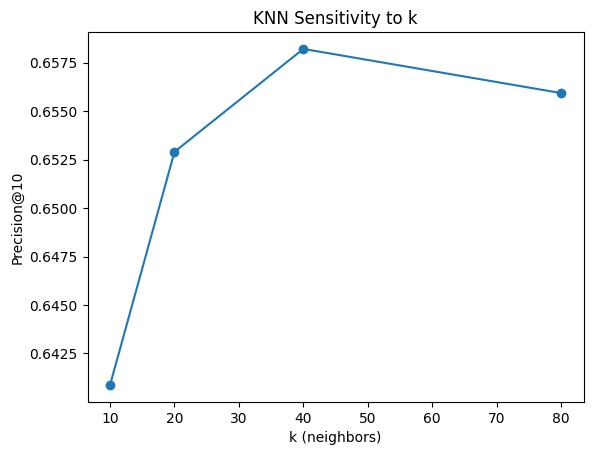

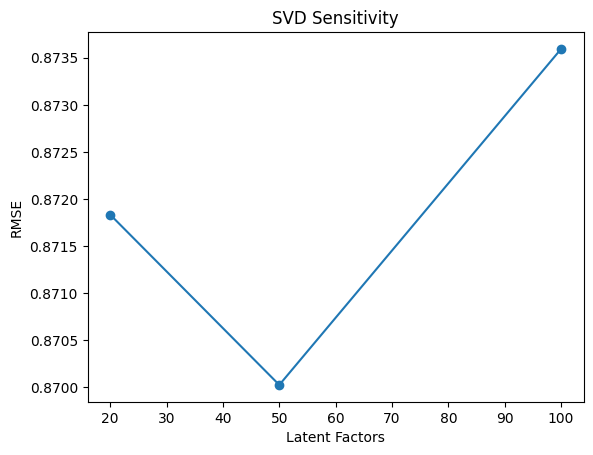

In [ ]:
# Extension B: Visualization

import matplotlib.pyplot as plt

# KNN plot
plt.figure()
plt.plot(knn_tuning_df["k"], knn_tuning_df["Precision@10"], marker='o')
plt.xlabel("k (neighbors)")
plt.ylabel("Precision@10")
plt.title("KNN Sensitivity to k")
plt.show()

# SVD plot
plt.figure()
plt.plot(svd_tuning_df["n_factors"], svd_tuning_df["RMSE"], marker='o')
plt.xlabel("Latent Factors")
plt.ylabel("RMSE")
plt.title("SVD Sensitivity")
plt.show()

In [ ]:
# PyTorch preprocessing for NCF / LightGCN

from sklearn.model_selection import KFold as SKKFold
import torch
from torch import nn
from torch.utils.data import Dataset as TorchDataset, DataLoader
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

user_codes = ratings["userId"].astype("category").cat.codes
item_codes = ratings["itemId"].astype("category").cat.codes

torch_df = ratings.copy()
torch_df["user_idx"] = user_codes
torch_df["item_idx"] = item_codes
torch_df["label"] = (torch_df["rating"] >= 4).astype(float)

num_users = torch_df.user_idx.nunique()
num_items = torch_df.item_idx.nunique()

num_users, num_items

cuda


(6040, 3706)

In [ ]:
# Create shared train/test split for full-ranking experiments

kf = SKKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(kf.split(torch_df))

train_df = torch_df.iloc[train_idx].reset_index(drop=True)
test_df = torch_df.iloc[test_idx].reset_index(drop=True)

idx_to_user = (
    torch_df[["user_idx", "userId"]]
    .drop_duplicates()
    .sort_values("user_idx")["userId"]
    .values
)

idx_to_item = (
    torch_df[["item_idx", "itemId"]]
    .drop_duplicates()
    .sort_values("item_idx")["itemId"]
    .values
)

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)
print("num_users:", num_users)
print("num_items:", num_items)

train_df: (800167, 7)
test_df: (200042, 7)
num_users: 6040
num_items: 3706


In [ ]:
# Dataset with negative sampling for implicit ranking

class InteractionDataset(TorchDataset):
    """
    PyTorch dataset that creates positive and negative user-item examples.
    Each observed user-item interaction is treated as a positive example.
    For each positive example, num_neg unobserved items are sampled as negatives.
    """
    def __init__(self, df, num_items, num_neg=4):
        self.users = df.user_idx.values
        self.items = df.item_idx.values
        self.labels = np.ones(len(df), dtype=np.float32)
        self.num_items = num_items
        self.num_neg = num_neg
        self.user_pos = df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    def __len__(self):
        return len(self.users) * (1 + self.num_neg)

    def __getitem__(self, idx):
        real_idx = idx // (1 + self.num_neg)
        is_pos = idx % (1 + self.num_neg) == 0

        user = self.users[real_idx]

        if is_pos:
            item = self.items[real_idx]
            label = 1.0
        else:
            while True:
                item = np.random.randint(0, self.num_items)
                if item not in self.user_pos.get(user, set()):
                    break
            label = 0.0

        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(item, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )

In [ ]:
# NCF model

class NCF(nn.Module):
    """
    Neural Collaborative Filtering model combining GMF and MLP components.
    The GMF branch captures linear user-item interactions.
    The MLP branch captures nonlinear user-item interactions.
    Their outputs are concatenated and passed to a final prediction layer.
    """
    def __init__(self, num_users, num_items, emb_dim=64):
        super().__init__()

        self.gmf_user = nn.Embedding(num_users, emb_dim)
        self.gmf_item = nn.Embedding(num_items, emb_dim)

        self.mlp_user = nn.Embedding(num_users, emb_dim)
        self.mlp_item = nn.Embedding(num_items, emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.out = nn.Linear(emb_dim + 16, 1)

    def forward(self, user, item):
        """
        Produces a predicted interaction score for each user-item pair.
        """
        gmf = self.gmf_user(user) * self.gmf_item(item)
        mlp_in = torch.cat([self.mlp_user(user), self.mlp_item(item)], dim=1)
        mlp_out = self.mlp(mlp_in)
        x = torch.cat([gmf, mlp_out], dim=1)
        return self.out(x).squeeze()

In [ ]:
# Train NCF on one split first

def train_ncf(train_df, epochs=3, batch_size=2048, lr=0.001):
    """
    Trains the NCF model using binary cross-entropy loss with negative sampling.
    """
    model = NCF(num_users, num_items, emb_dim=64).to(device)
    dataset = InteractionDataset(train_df, num_items=num_items, num_neg=4)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for user, item, label in tqdm(loader):
            user, item, label = user.to(device), item.to(device), label.to(device)

            opt.zero_grad()
            logits = model(user, item)
            loss = loss_fn(logits, label)
            loss.backward()
            opt.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, loss={total_loss/len(loader):.4f}")

    return model

In [ ]:
# Evaluate NCF on observed test pairs

def evaluate_torch_model(model, test_df, model_name):
    """
    Evaluates a PyTorch recommender model on observed test interactions only.
    """
    model.eval()

    users = torch.tensor(test_df.user_idx.values, dtype=torch.long).to(device)
    items = torch.tensor(test_df.item_idx.values, dtype=torch.long).to(device)

    preds = []
    with torch.no_grad():
        for start in range(0, len(test_df), 8192):
            batch_users = users[start:start+8192]
            batch_items = items[start:start+8192]
            score = torch.sigmoid(model(batch_users, batch_items)).cpu().numpy()
            preds.extend(score)

    pred_df = test_df[["userId", "itemId"]].copy()
    pred_df["prediction"] = preds

    test_eval = test_df[["userId", "itemId", "rating"]].copy()
    rank_metrics = precision_recall_ndcg_at_k(test_eval, pred_df, k=10)

    return {
        "model": model_name,
        **rank_metrics
    }

In [ ]:
# Cell 14 - Full-ranking NCF evaluation

ncf_model = train_ncf(train_df, epochs=20)

def evaluate_ncf_full_ranking(model, train_df, test_df, k=10):
    """
    Evaluates the NCF model using full-ranking top-k evaluation.
    """
    model.eval()

    all_items = torch.arange(num_items, dtype=torch.long).to(device)

    def score_matrix(batch_users):
        """
        Builds a dense [batch_size, num_items] score matrix for NCF.
        """
        batch_size = batch_users.shape[0]

        users_expanded = batch_users.repeat_interleave(num_items)
        items_expanded = all_items.repeat(batch_size)

        scores = model(users_expanded, items_expanded)
        return scores.view(batch_size, num_items)

    result = full_ranking_metrics_from_score_matrix(
        score_matrix=score_matrix,
        train_df=train_df,
        test_df=test_df,
        k=k
    )

    return {
        "model": "NCF Full Ranking",
        **result
    }

ncf_one_fold_results = evaluate_ncf_full_ranking(
    ncf_model,
    train_df,
    test_df,
    k=10
)

ncf_one_fold_results

100%|██████████| 1954/1954 [02:14<00:00, 14.56it/s]


Epoch 1, loss=0.3911


100%|██████████| 1954/1954 [02:08<00:00, 15.25it/s]


Epoch 2, loss=0.3653


100%|██████████| 1954/1954 [02:06<00:00, 15.42it/s]


...

Epoch 19, loss=0.2594


100%|██████████| 1954/1954 [02:06<00:00, 15.44it/s]


Epoch 20, loss=0.2543


Full-ranking eval: 100%|██████████| 24/24 [00:02<00:00, 10.30it/s]


{'model': 'NCF Full Ranking',
 'Precision@10': 0.16930263596930262,
 'Recall@10': 0.10969038257831439,
 'F1@10': 0.13312785393459817,
 'NDCG@10': 0.19579643711635197}

In [ ]:
# LightGCN skeleton

class LightGCN(nn.Module):
    """
    LightGCN model for collaborative filtering.
    """
    def __init__(self, num_users, num_items, emb_dim=64, n_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.n_layers = n_layers

        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

    def forward(self, edge_index):
        """
        edge_index shape: [2, num_edges]
        First row = user indices
        Second row = item indices
        This simplified version keeps the core LightGCN idea:
        repeated normalized neighbor aggregation, then mean over layers.
        """
        user_e = self.user_emb.weight
        item_e = self.item_emb.weight

        all_user_e = [user_e]
        all_item_e = [item_e]

        users = edge_index[0]
        items = edge_index[1]

        for _ in range(self.n_layers):
            new_user = torch.zeros_like(user_e)
            new_item = torch.zeros_like(item_e)

            new_user.index_add_(0, users, item_e[items])
            new_item.index_add_(0, items, user_e[users])

            user_deg = torch.bincount(users, minlength=self.num_users).clamp(min=1).float().to(device).unsqueeze(1)
            item_deg = torch.bincount(items, minlength=self.num_items).clamp(min=1).float().to(device).unsqueeze(1)

            user_e = new_user / user_deg
            item_e = new_item / item_deg

            all_user_e.append(user_e)
            all_item_e.append(item_e)

        final_user = torch.stack(all_user_e).mean(dim=0)
        final_item = torch.stack(all_item_e).mean(dim=0)

        return final_user, final_item

    def predict(self, users, items, edge_index):
        """
        Computes dot-product scores for selected user-item pairs.
        """
        user_e, item_e = self.forward(edge_index)
        return (user_e[users] * item_e[items]).sum(dim=1)

In [ ]:
# Train LightGCN with BPR loss

def bpr_loss(pos_scores, neg_scores):
    """
    Computes the BPR loss for a batch of positive and negative scores.
    """
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))

def build_edge_index(train_df):
    """
    Builds the user-item edge index tensor used by LightGCN propagation.
    """
    users = torch.tensor(train_df.user_idx.values, dtype=torch.long)
    items = torch.tensor(train_df.item_idx.values, dtype=torch.long)
    return torch.stack([users, items]).to(device)

def train_lightgcn(train_df, epochs=3, batch_size=4096, lr=0.001):
    """
    Trains the LightGCN model using BPR loss and random negative sampling.
    """
    model = LightGCN(num_users, num_items, emb_dim=64, n_layers=3).to(device)
    edge_index = build_edge_index(train_df)

    user_pos = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()
    train_pairs = train_df[["user_idx", "item_idx"]].values

    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        np.random.shuffle(train_pairs)
        losses = []

        for start in tqdm(range(0, len(train_pairs), batch_size)):
            batch = train_pairs[start:start+batch_size]
            users_np = batch[:, 0]
            pos_items_np = batch[:, 1]

            neg_items_np = []
            for u in users_np:
                while True:
                    neg = np.random.randint(0, num_items)
                    if neg not in user_pos.get(u, set()):
                        neg_items_np.append(neg)
                        break

            users = torch.tensor(users_np, dtype=torch.long).to(device)
            pos_items = torch.tensor(pos_items_np, dtype=torch.long).to(device)
            neg_items = torch.tensor(neg_items_np, dtype=torch.long).to(device)

            opt.zero_grad()
            user_e, item_e = model(edge_index)

            pos_scores = (user_e[users] * item_e[pos_items]).sum(dim=1)
            neg_scores = (user_e[users] * item_e[neg_items]).sum(dim=1)

            loss = bpr_loss(pos_scores, neg_scores)
            loss.backward()
            opt.step()

            losses.append(loss.item())

        print(f"Epoch {epoch+1}, BPR loss={np.mean(losses):.4f}")

    return model, edge_index

In [ ]:
# Full-ranking LightGCN evaluation

lightgcn_model, edge_index = train_lightgcn(train_df, epochs=50)

def evaluate_lightgcn_full_ranking(model, edge_index, train_df, test_df, k=10):
    """
    Evaluates the LightGCN model using full-ranking top-k evaluation.
    """
    model.eval()

    with torch.no_grad():
        user_e, item_e = model(edge_index)

    def score_matrix(batch_users):
        """
        Builds a dense [batch_size, num_items] score matrix for LightGCN.
        """
        return user_e[batch_users] @ item_e.T

    result = full_ranking_metrics_from_score_matrix(
        score_matrix=score_matrix,
        train_df=train_df,
        test_df=test_df,
        k=k
    )

    return {
        "model": "LightGCN Full Ranking",
        **result
    }

lightgcn_one_fold_results = evaluate_lightgcn_full_ranking(
    lightgcn_model,
    edge_index,
    train_df,
    test_df,
    k=10
)

lightgcn_one_fold_results

100%|██████████| 196/196 [00:16<00:00, 12.24it/s]


Epoch 1, BPR loss=0.6353


100%|██████████| 196/196 [00:15<00:00, 12.44it/s]


Epoch 2, BPR loss=0.3954


100%|██████████| 196/196 [00:15<00:00, 12.60it/s]


...

Epoch 49, BPR loss=0.2005


100%|██████████| 196/196 [00:15<00:00, 12.55it/s]


Epoch 50, BPR loss=0.1994


Full-ranking eval: 100%|██████████| 24/24 [00:00<00:00, 24.23it/s]


{'model': 'LightGCN Full Ranking',
 'Precision@10': 0.23872205538872207,
 'Recall@10': 0.16051413008270743,
 'F1@10': 0.1919578657782702,
 'NDCG@10': 0.29105111633299935}

In [ ]:
# Full-ranking baselines: Popularity, KNNBasic Item-Item, and SVD evaluates traditional models using the same full-ranking setup as NCF and LightGCN.


from surprise import Dataset, Reader, KNNBasic, SVD

# Shared raw id mappings between torch indices and MovieLens ids
idx_to_user = (
    torch_df[["user_idx", "userId"]]
    .drop_duplicates()
    .sort_values("user_idx")["userId"]
    .values
)

idx_to_item = (
    torch_df[["item_idx", "itemId"]]
    .drop_duplicates()
    .sort_values("item_idx")["itemId"]
    .values
)


def build_surprise_trainset_from_torch_split(train_df):
    """
    Converts the current train split into a Surprise Trainset object.
    """
    reader = Reader(rating_scale=(1, 5))

    surprise_train_data = Dataset.load_from_df(
        train_df[["userId", "itemId", "rating"]],
        reader
    )

    trainset = surprise_train_data.build_full_trainset()
    return trainset


def build_surprise_index_maps(trainset):
    """
    Builds mappings from torch-style user/item indices to Surprise inner IDs.
    """
    user_inner_ids = np.full(num_users, -1, dtype=np.int64)
    item_inner_ids = np.full(num_items, -1, dtype=np.int64)

    for user_idx in range(num_users):
        raw_uid = idx_to_user[user_idx]
        try:
            user_inner_ids[user_idx] = trainset.to_inner_uid(raw_uid)
        except ValueError:
            user_inner_ids[user_idx] = -1

    for item_idx in range(num_items):
        raw_iid = idx_to_item[item_idx]
        try:
            item_inner_ids[item_idx] = trainset.to_inner_iid(raw_iid)
        except ValueError:
            item_inner_ids[item_idx] = -1

    return user_inner_ids, item_inner_ids

In [ ]:
# Popularity Full Ranking

def evaluate_popularity_full_ranking(train_df, test_df, k=10):
    """
    Evaluates a popularity baseline using full-ranking top-k evaluation.

    Items are scored by how many high ratings they received in the training set.
    """
    item_popularity = (
        train_df[train_df["rating"] >= 4]
        .groupby("item_idx")
        .size()
        .reindex(range(num_items), fill_value=0)
        .values
        .astype(np.float32)
    )

    item_popularity = torch.tensor(item_popularity, dtype=torch.float32).to(device)

    def score_matrix(batch_users):
        """
        Returns the same item-popularity scores for every user in the batch.
        """
        batch_size = batch_users.shape[0]
        return item_popularity.unsqueeze(0).repeat(batch_size, 1)

    result = full_ranking_metrics_from_score_matrix(
        score_matrix=score_matrix,
        train_df=train_df,
        test_df=test_df,
        k=k
    )

    return {
        "model": "Popularity Full Ranking",
        **result
    }


popularity_full_ranking_results = evaluate_popularity_full_ranking(
    train_df,
    test_df,
    k=10
)

popularity_full_ranking_results

Full-ranking eval: 100%|██████████| 24/24 [00:01<00:00, 23.58it/s]


{'model': 'Popularity Full Ranking',
 'Precision@10': 0.15195195195195194,
 'Recall@10': 0.09068971711376803,
 'F1@10': 0.11358708164569148,
 'NDCG@10': 0.17668139131631683}

In [ ]:
# SVD Full Ranking

def train_svd_full_ranking_model(train_df):
    """
    Trains an SVD model on the current train split.
    """
    trainset = build_surprise_trainset_from_torch_split(train_df)

    svd_model = SVD(
        n_factors=100,
        n_epochs=20,
        lr_all=0.005,
        reg_all=0.02,
        random_state=42
    )

    svd_model.fit(trainset)

    return svd_model, trainset


def evaluate_svd_full_ranking(svd_model, trainset, train_df, test_df, k=10):
    """
    Evaluates the SVD model using full-ranking top-k evaluation.
    """
    user_inner_ids, item_inner_ids = build_surprise_index_maps(trainset)

    n_factors = svd_model.qi.shape[1]

    user_factors = np.zeros((num_users, n_factors), dtype=np.float32)
    user_biases = np.zeros(num_users, dtype=np.float32)

    item_factors = np.zeros((num_items, n_factors), dtype=np.float32)
    item_biases = np.zeros(num_items, dtype=np.float32)

    valid_users = user_inner_ids >= 0
    valid_items = item_inner_ids >= 0

    user_factors[valid_users] = svd_model.pu[user_inner_ids[valid_users]]
    user_biases[valid_users] = svd_model.bu[user_inner_ids[valid_users]]

    item_factors[valid_items] = svd_model.qi[item_inner_ids[valid_items]]
    item_biases[valid_items] = svd_model.bi[item_inner_ids[valid_items]]

    user_factors = torch.tensor(user_factors, dtype=torch.float32).to(device)
    user_biases = torch.tensor(user_biases, dtype=torch.float32).to(device)

    item_factors = torch.tensor(item_factors, dtype=torch.float32).to(device)
    item_biases = torch.tensor(item_biases, dtype=torch.float32).to(device)

    global_mean = torch.tensor(trainset.global_mean, dtype=torch.float32).to(device)

    def score_matrix(batch_users):
        """
        Builds a dense [batch_size, num_items] score matrix using the SVD formula
        """
        batch_user_factors = user_factors[batch_users]
        batch_user_biases = user_biases[batch_users]

        scores = (
            global_mean
            + batch_user_biases.unsqueeze(1)
            + item_biases.unsqueeze(0)
            + batch_user_factors @ item_factors.T
        )

        return scores

    result = full_ranking_metrics_from_score_matrix(
        score_matrix=score_matrix,
        train_df=train_df,
        test_df=test_df,
        k=k
    )

    return {
        "model": "SVD Full Ranking",
        **result
    }


svd_full_model, svd_full_trainset = train_svd_full_ranking_model(train_df)

svd_full_ranking_results = evaluate_svd_full_ranking(
    svd_full_model,
    svd_full_trainset,
    train_df,
    test_df,
    k=10
)

svd_full_ranking_results

Full-ranking eval: 100%|██████████| 24/24 [00:01<00:00, 23.65it/s]


{'model': 'SVD Full Ranking',
 'Precision@10': 0.07809476142809477,
 'Recall@10': 0.043340744185683906,
 'F1@10': 0.05574457091753612,
 'NDCG@10': 0.09170102163736717}

In [ ]:
# KNNBasic Item-Item Full Ranking

def train_knn_full_ranking_model(train_df):
    """
    Trains a Surprise item-item KNNBasic model on the current train split.
    """
    trainset = build_surprise_trainset_from_torch_split(train_df)

    knn_model = KNNBasic(
        k=40,
        min_k=1,
        sim_options={
            "name": "cosine",
            "user_based": False
        }
    )

    knn_model.fit(trainset)

    return knn_model, trainset


def evaluate_knn_item_item_full_ranking(
    knn_model,
    trainset,
    train_df,
    test_df,
    k=10,
    knn_k=40,
    batch_users=32
):
    """
    Evaluates the KNNBasic model using full-ranking top-k evaluation.
    """
    user_inner_ids, item_inner_ids = build_surprise_index_maps(trainset)

    sim = knn_model.sim.astype(np.float32)

    valid_items = item_inner_ids >= 0
    safe_item_inner_ids = np.where(valid_items, item_inner_ids, 0)

    # Rows are in torch item_idx order
    sim_rows_by_torch_item = sim[safe_item_inner_ids]

    train_seen = train_df.groupby("user_idx")["item_idx"].apply(set).to_dict()

    test_relevant = (
        test_df[test_df["rating"] >= 4.0]
        .groupby("user_idx")["item_idx"]
        .apply(set)
        .to_dict()
    )

    users_to_eval = sorted(test_relevant.keys())

    precisions = []
    recalls = []
    ndcgs = []

    for start in tqdm(range(0, len(users_to_eval), batch_users), desc="KNN full-ranking eval"):
        batch_user_list = users_to_eval[start:start + batch_users]

        batch_scores = []

        for user_idx in batch_user_list:
            inner_uid = user_inner_ids[user_idx]

            # Cold-start fallback
            if inner_uid < 0:
                user_scores = np.full(num_items, trainset.global_mean, dtype=np.float32)
            else:
                rated_items = trainset.ur[inner_uid]

                if len(rated_items) == 0:
                    user_scores = np.full(num_items, trainset.global_mean, dtype=np.float32)
                else:
                    rated_inner_items = np.array([iid for iid, _ in rated_items], dtype=np.int64)
                    rated_values = np.array([rating for _, rating in rated_items], dtype=np.float32)

                    # Similarities from each candidate item to the user's rated items
                    sim_sub = sim_rows_by_torch_item[:, rated_inner_items]

                    # Only positive similarities count
                    sim_sub = np.where(sim_sub > 0, sim_sub, 0.0)

                    actual_k = min(knn_k, sim_sub.shape[1])

                    if actual_k < sim_sub.shape[1]:
                        top_idx = np.argpartition(sim_sub, -actual_k, axis=1)[:, -actual_k:]
                        top_sims = np.take_along_axis(sim_sub, top_idx, axis=1)
                        top_ratings = rated_values[top_idx]
                    else:
                        top_sims = sim_sub
                        top_ratings = rated_values.reshape(1, -1)

                    sum_sims = top_sims.sum(axis=1)
                    weighted_sum = (top_sims * top_ratings).sum(axis=1)

                    user_scores = np.divide(
                        weighted_sum,
                        sum_sims,
                        out=np.full(num_items, trainset.global_mean, dtype=np.float32),
                        where=sum_sims > 0
                    )

                    user_scores[~valid_items] = trainset.global_mean

            # Remove training items
            for seen_item in train_seen.get(user_idx, set()):
                user_scores[seen_item] = -np.inf

            batch_scores.append(user_scores)

        batch_scores = np.stack(batch_scores, axis=0)

        for row_idx, user_idx in enumerate(batch_user_list):
            user_scores = batch_scores[row_idx]

            top_items = np.argsort(-user_scores)[:k]
            relevant_items = test_relevant.get(user_idx, set())

            hits = [1 if item in relevant_items else 0 for item in top_items]

            precision = sum(hits) / k
            recall = sum(hits) / len(relevant_items) if len(relevant_items) > 0 else 0

            dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))

            ideal_hits = [1] * min(len(relevant_items), k)
            idcg = sum(ideal_hits[i] / np.log2(i + 2) for i in range(len(ideal_hits)))

            ndcg = dcg / idcg if idcg > 0 else 0

            precisions.append(precision)
            recalls.append(recall)
            ndcgs.append(ndcg)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    avg_ndcg = np.mean(ndcgs)

    return {
        "model": "KNNBasic Item-Item Full Ranking",
        "Precision@10": avg_precision,
        "Recall@10": avg_recall,
        "F1@10": f1_at_k(avg_precision, avg_recall),
        "NDCG@10": avg_ndcg
    }


knn_full_model, knn_full_trainset = train_knn_full_ranking_model(train_df)

knn_full_ranking_results = evaluate_knn_item_item_full_ranking(
    knn_full_model,
    knn_full_trainset,
    train_df,
    test_df,
    k=10,
    knn_k=40,
    batch_users=32
)

knn_full_ranking_results

Computing the cosine similarity matrix...
Done computing similarity matrix.


KNN full-ranking eval: 100%|██████████| 76/76 [00:02<00:00, 34.70it/s]


{'model': 'KNNBasic Item-Item Full Ranking',
 'Precision@10': 0.0013613861386138615,
 'Recall@10': 0.0047245365200680465,
 'F1@10': 0.002113703670098442,
 'NDCG@10': 0.0032956185285497276}

In [ ]:
# Final full-ranking comparison table

full_ranking_results = pd.DataFrame([
    popularity_full_ranking_results,
    knn_full_ranking_results,
    svd_full_ranking_results,
    ncf_one_fold_results,
    lightgcn_one_fold_results
])

full_ranking_results = full_ranking_results.sort_values(
    by="NDCG@10",
    ascending=False
).reset_index(drop=True)

display(full_ranking_results)

print("Older 5-fold rating-prediction baseline results:")
display(
    baseline_results.groupby("model").mean(numeric_only=True)
)

,model,Precision@10,Recall@10,F1@10,NDCG@10
0,LightGCN Full Ranking,0.238722,0.160514,0.191958,0.291051
1,NCF Full Ranking,0.169303,0.109690,0.133128,0.195796
2,Popularity Full Ranking,0.151952,0.090690,0.113587,0.176681
3,SVD Full Ranking,0.078095,0.043341,0.055745,0.091701
4,KNNBasic Item-Item Full Ranking,0.001361,0.004725,0.002114,0.003296


Older 5-fold rating-prediction baseline results:


,fold,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage
model,,,,,,,
KNNBasic Item-Item,3.0,0.999265,0.780313,0.658211,0.61988,0.825194,0.690880
SVD,3.0,0.873594,0.685717,0.682100,0.63428,0.865867,0.659471


In [ ]:
# Save MovieLens 1M results before running new datasets

ml1m_full_ranking_results = full_ranking_results.copy()
ml1m_full_ranking_results["dataset"] = "MovieLens 1M"

display(ml1m_full_ranking_results)

,model,Precision@10,Recall@10,F1@10,NDCG@10,dataset
0,LightGCN Full Ranking,0.238722,0.160514,0.191958,0.291051,MovieLens 1M
1,NCF Full Ranking,0.169303,0.109690,0.133128,0.195796,MovieLens 1M
2,Popularity Full Ranking,0.151952,0.090690,0.113587,0.176681,MovieLens 1M
3,SVD Full Ranking,0.078095,0.043341,0.055745,0.091701,MovieLens 1M
4,KNNBasic Item-Item Full Ranking,0.001361,0.004725,0.002114,0.003296,MovieLens 1M


In [ ]:
# Prepare external datasets for same pipeline

import os
import glob
import zipfile
import urllib.request

def prepare_external_dataset(
    raw_df,
    dataset_name,
    user_col,
    item_col,
    rating_col,
    min_user_interactions=5,
    min_item_interactions=5,
    max_users=3000,
    max_items=3000,
    random_state=42
):
    """
    Converts an external recommendation dataset into the same format
    used by the MovieLens 1M pipeline.

    It overwrites:
    ratings, torch_df, train_df, test_df, num_users, num_items,
    idx_to_user, idx_to_item

    This is intentional so the existing NCF, LightGCN, SVD, KNN,
    and full-ranking evaluation functions can be reused.
    """

    global ratings, torch_df, train_df, test_df
    global num_users, num_items, idx_to_user, idx_to_item

    df = raw_df[[user_col, item_col, rating_col]].copy()
    df = df.rename(
        columns={
            user_col: "userId",
            item_col: "itemId",
            rating_col: "rating"
        }
    )

    df = df.dropna()
    df["rating"] = df["rating"].astype(float)

    # Average duplicate user-item interactions if they exist
    df = (
        df.groupby(["userId", "itemId"], as_index=False)["rating"]
        .mean()
    )

    # Repeated filtering helps after removing sparse users/items
    for _ in range(3):
        user_counts = df["userId"].value_counts()
        item_counts = df["itemId"].value_counts()

        keep_users = user_counts[user_counts >= min_user_interactions].index
        keep_items = item_counts[item_counts >= min_item_interactions].index

        df = df[
            df["userId"].isin(keep_users)
            & df["itemId"].isin(keep_items)
        ].copy()

    # Cap size so KNN similarity and full-ranking eval stay reasonable
    top_users = df["userId"].value_counts().head(max_users).index
    top_items = df["itemId"].value_counts().head(max_items).index

    df = df[
        df["userId"].isin(top_users)
        & df["itemId"].isin(top_items)
    ].copy()

    # Final cleanup after top-user/top-item filtering
    for _ in range(2):
        user_counts = df["userId"].value_counts()
        item_counts = df["itemId"].value_counts()

        keep_users = user_counts[user_counts >= min_user_interactions].index
        keep_items = item_counts[item_counts >= min_item_interactions].index

        df = df[
            df["userId"].isin(keep_users)
            & df["itemId"].isin(keep_items)
        ].copy()

    ratings = df.reset_index(drop=True)

    torch_df = ratings.copy()
    torch_df["user_idx"] = torch_df["userId"].astype("category").cat.codes
    torch_df["item_idx"] = torch_df["itemId"].astype("category").cat.codes
    torch_df["label"] = (torch_df["rating"] >= 4.0).astype(float)

    num_users = torch_df["user_idx"].nunique()
    num_items = torch_df["item_idx"].nunique()

    kf = SKKFold(n_splits=5, shuffle=True, random_state=random_state)
    train_idx, test_idx = next(kf.split(torch_df))

    train_df = torch_df.iloc[train_idx].reset_index(drop=True)
    test_df = torch_df.iloc[test_idx].reset_index(drop=True)

    idx_to_user = (
        torch_df[["user_idx", "userId"]]
        .drop_duplicates()
        .sort_values("user_idx")["userId"]
        .values
    )

    idx_to_item = (
        torch_df[["item_idx", "itemId"]]
        .drop_duplicates()
        .sort_values("item_idx")["itemId"]
        .values
    )

    stats = {
        "dataset": dataset_name,
        "rows": len(torch_df),
        "users": num_users,
        "items": num_items,
        "sparsity": 1 - len(torch_df) / (num_users * num_items)
    }

    print(f"Prepared {dataset_name}")
    print(stats)
    print("Train rows:", len(train_df))
    print("Test rows:", len(test_df))

    return stats

In [ ]:
# Run all full-ranking models on current dataset

def run_full_ranking_experiment_for_current_dataset(
    dataset_name,
    ncf_epochs=20,
    lightgcn_epochs=50,
    include_knn=True
):
    """
    Runs the full-ranking experiment on whichever dataset is currently stored
    in the global train_df and test_df variables.
    """
    results = []

    print(f"\nRunning Popularity on {dataset_name}...")
    popularity_results = evaluate_popularity_full_ranking(
        train_df,
        test_df,
        k=10
    )
    results.append(popularity_results)

    print(f"\nRunning SVD on {dataset_name}...")
    svd_model, svd_trainset = train_svd_full_ranking_model(train_df)

    svd_results = evaluate_svd_full_ranking(
        svd_model,
        svd_trainset,
        train_df,
        test_df,
        k=10
    )
    results.append(svd_results)

    if include_knn:
        print(f"\nRunning KNNBasic Item-Item on {dataset_name}...")
        knn_model, knn_trainset = train_knn_full_ranking_model(train_df)

        knn_results = evaluate_knn_item_item_full_ranking(
            knn_model,
            knn_trainset,
            train_df,
            test_df,
            k=10,
            knn_k=40,
            batch_users=32
        )
        results.append(knn_results)

    print(f"\nRunning NCF on {dataset_name}...")
    ncf_model = train_ncf(
        train_df,
        epochs=ncf_epochs
    )

    ncf_results = evaluate_ncf_full_ranking(
        ncf_model,
        train_df,
        test_df,
        k=10
    )
    results.append(ncf_results)

    print(f"\nRunning LightGCN on {dataset_name}...")
    lightgcn_model, edge_index = train_lightgcn(
        train_df,
        epochs=lightgcn_epochs
    )

    lightgcn_results = evaluate_lightgcn_full_ranking(
        lightgcn_model,
        edge_index,
        train_df,
        test_df,
        k=10
    )
    results.append(lightgcn_results)

    result_df = pd.DataFrame(results)
    result_df["dataset"] = dataset_name

    result_df = result_df.sort_values(
        by="NDCG@10",
        ascending=False
    ).reset_index(drop=True)

    display(result_df)

    return result_df

In [ ]:
# Cross-domain dataset helper functions

from sklearn.model_selection import KFold as SKKFold

def filter_interactions(
    df,
    user_col,
    item_col,
    min_user_interactions=5,
    min_item_interactions=5,
    max_users=None,
    max_items=None,
    n_iter=5
):
    """
    Filters a recommendation dataset to keep users and items with enough
    interactions, optionally capping the number of users and items.
    """
    df = df.copy()

    for _ in range(n_iter):
        user_counts = df[user_col].value_counts()
        item_counts = df[item_col].value_counts()

        keep_users = user_counts[user_counts >= min_user_interactions].index
        keep_items = item_counts[item_counts >= min_item_interactions].index

        df = df[
            df[user_col].isin(keep_users) &
            df[item_col].isin(keep_items)
        ].copy()

    if max_users is not None:
        top_users = df[user_col].value_counts().head(max_users).index
        df = df[df[user_col].isin(top_users)].copy()

    if max_items is not None:
        top_items = df[item_col].value_counts().head(max_items).index
        df = df[df[item_col].isin(top_items)].copy()

    for _ in range(n_iter):
        user_counts = df[user_col].value_counts()
        item_counts = df[item_col].value_counts()

        keep_users = user_counts[user_counts >= min_user_interactions].index
        keep_items = item_counts[item_counts >= min_item_interactions].index

        df = df[
            df[user_col].isin(keep_users) &
            df[item_col].isin(keep_items)
        ].copy()

    return df.reset_index(drop=True)


def prepare_dataset_for_existing_pipeline(
    df,
    user_col,
    item_col,
    rating_col,
    dataset_name,
    min_user_interactions=5,
    min_item_interactions=5,
    max_users=None,
    max_items=None
):
    """
    Prepares a cross-domain dataset for reuse with the existing MovieLens pipeline.
    """
    global ratings, torch_df, train_df, test_df
    global num_users, num_items
    global idx_to_user, idx_to_item

    filtered = filter_interactions(
        df=df,
        user_col=user_col,
        item_col=item_col,
        min_user_interactions=min_user_interactions,
        min_item_interactions=min_item_interactions,
        max_users=max_users,
        max_items=max_items
    )

    ratings = filtered[[user_col, item_col, rating_col]].copy()
    ratings.columns = ["userId", "itemId", "rating"]
    ratings["rating"] = ratings["rating"].astype(float)

    torch_df = ratings.copy()
    torch_df["user_idx"] = torch_df["userId"].astype("category").cat.codes
    torch_df["item_idx"] = torch_df["itemId"].astype("category").cat.codes
    torch_df["label"] = (torch_df["rating"] >= 4).astype(float)

    num_users = torch_df["user_idx"].nunique()
    num_items = torch_df["item_idx"].nunique()

    kf = SKKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(torch_df))

    train_df = torch_df.iloc[train_idx].reset_index(drop=True)
    test_df = torch_df.iloc[test_idx].reset_index(drop=True)

    idx_to_user = (
        torch_df[["user_idx", "userId"]]
        .drop_duplicates()
        .sort_values("user_idx")["userId"]
        .values
    )

    idx_to_item = (
        torch_df[["item_idx", "itemId"]]
        .drop_duplicates()
        .sort_values("item_idx")["itemId"]
        .values
    )

    stats = {
        "dataset": dataset_name,
        "users": num_users,
        "items": num_items,
        "interactions": len(torch_df),
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "sparsity": 1 - len(torch_df) / (num_users * num_items)
    }

    print(f"\nPrepared {dataset_name}:")
    print(stats)

    return stats


def evaluate_ncf_full_ranking_safe(model, train_df, test_df, k=10, batch_users=32):
    """
    Full-ranking NCF evaluation for cross-domain datasets.
    """
    model.eval()

    all_items = torch.arange(num_items, dtype=torch.long).to(device)

    def score_matrix(batch_users_tensor):
        batch_size = batch_users_tensor.shape[0]

        users_expanded = batch_users_tensor.repeat_interleave(num_items)
        items_expanded = all_items.repeat(batch_size)

        scores = model(users_expanded, items_expanded)
        return scores.view(batch_size, num_items)

    result = full_ranking_metrics_from_score_matrix(
        score_matrix=score_matrix,
        train_df=train_df,
        test_df=test_df,
        k=k,
        batch_users=batch_users
    )

    return {
        "model": "NCF Full Ranking",
        **result
    }


def evaluate_lightgcn_full_ranking_safe(model, edge_index, train_df, test_df, k=10, batch_users=256):
    """
    Full-ranking LightGCN evaluation for cross-domain datasets.
    """
    model.eval()

    with torch.no_grad():
        user_e, item_e = model(edge_index)

    def score_matrix(batch_users_tensor):
        return user_e[batch_users_tensor] @ item_e.T

    result = full_ranking_metrics_from_score_matrix(
        score_matrix=score_matrix,
        train_df=train_df,
        test_df=test_df,
        k=k,
        batch_users=batch_users
    )

    return {
        "model": "LightGCN Full Ranking",
        **result
    }


def run_cross_domain_full_ranking_experiment(
    dataset_name,
    df,
    user_col,
    item_col,
    rating_col,
    min_user_interactions=5,
    min_item_interactions=5,
    max_users=None,
    max_items=None,
    ncf_epochs=10,
    lightgcn_epochs=25,
    run_knn=True
):
    """
    Runs the full-ranking experiment on a cross-domain dataset.
    """
    stats = prepare_dataset_for_existing_pipeline(
        df=df,
        user_col=user_col,
        item_col=item_col,
        rating_col=rating_col,
        dataset_name=dataset_name,
        min_user_interactions=min_user_interactions,
        min_item_interactions=min_item_interactions,
        max_users=max_users,
        max_items=max_items
    )

    results = []

    print(f"\nRunning Popularity on {dataset_name}...")
    popularity_result = evaluate_popularity_full_ranking(
        train_df,
        test_df,
        k=10
    )
    results.append(popularity_result)

    print(f"\nRunning SVD on {dataset_name}...")
    svd_model, svd_trainset = train_svd_full_ranking_model(train_df)
    svd_result = evaluate_svd_full_ranking(
        svd_model,
        svd_trainset,
        train_df,
        test_df,
        k=10
    )
    results.append(svd_result)

    if run_knn:
        print(f"\nRunning KNNBasic Item-Item on {dataset_name}...")
        knn_model, knn_trainset = train_knn_full_ranking_model(train_df)
        knn_result = evaluate_knn_item_item_full_ranking(
            knn_model,
            knn_trainset,
            train_df,
            test_df,
            k=10,
            knn_k=40,
            batch_users=32
        )
        results.append(knn_result)

    print(f"\nRunning NCF on {dataset_name}...")
    ncf_model = train_ncf(train_df, epochs=ncf_epochs)
    ncf_result = evaluate_ncf_full_ranking_safe(
        ncf_model,
        train_df,
        test_df,
        k=10,
        batch_users=32
    )
    results.append(ncf_result)

    print(f"\nRunning LightGCN on {dataset_name}...")
    lightgcn_model, edge_index = train_lightgcn(
        train_df,
        epochs=lightgcn_epochs
    )
    lightgcn_result = evaluate_lightgcn_full_ranking_safe(
        lightgcn_model,
        edge_index,
        train_df,
        test_df,
        k=10,
        batch_users=256
    )
    results.append(lightgcn_result)

    results_df = pd.DataFrame(results)
    results_df["dataset"] = dataset_name

    results_df = results_df.sort_values(
        by="NDCG@10",
        ascending=False
    ).reset_index(drop=True)

    stats_df = pd.DataFrame([stats])

    print(f"\nFinal results for {dataset_name}:")
    display(results_df)

    return results_df, stats_df


print("Cross-domain helper functions loaded.")

SyntaxError: incomplete input (179481916.py, line 133)

In [ ]:
# Extension Dataset: Last.fm HetRec 2011

lastfm_url = "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"
lastfm_zip = "hetrec2011-lastfm-2k.zip"

if not os.path.exists(lastfm_zip):
    urllib.request.urlretrieve(lastfm_url, lastfm_zip)

with zipfile.ZipFile(lastfm_zip, "r") as z:
    z.extractall("lastfm_data")

lastfm_path = glob.glob(
    "lastfm_data/**/user_artists.dat",
    recursive=True
)[0]

lastfm_raw = pd.read_csv(
    lastfm_path,
    sep="\t"
)

print(lastfm_raw.head())
print(lastfm_raw.shape)

   userID  artistID  weight
0       2        51   13883
1       2        52   11690
2       2        53   11351
3       2        54   10300
4       2        55    8983
(92834, 3)


In [ ]:
# Prepare Last.fm for full-ranking experiment

lastfm_df = lastfm_raw.copy()

# user_artists.dat usually has columns:
# userID, artistID, weight
lastfm_df = lastfm_df.rename(
    columns={
        "userID": "userId",
        "artistID": "itemId",
        "weight": "listen_count"
    }
)

lastfm_df["log_listen_count"] = np.log1p(lastfm_df["listen_count"])

def scale_user_listens_to_rating(series):
    """
    Scales user listening counts to a 1-5 pseudo-rating.
    """
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return pd.Series(
            np.full(len(series), 5.0),
            index=series.index
        )

    return 1 + 4 * ((series - min_val) / (max_val - min_val))

lastfm_df["rating_scaled"] = (
    lastfm_df.groupby("userId")["log_listen_count"]
    .transform(scale_user_listens_to_rating)
)

lastfm_stats = prepare_external_dataset(
    raw_df=lastfm_df,
    dataset_name="Last.fm HetRec 2011",
    user_col="userId",
    item_col="itemId",
    rating_col="rating_scaled",
    min_user_interactions=5,
    min_item_interactions=5,
    max_users=3000,
    max_items=3000
)

Prepared Last.fm HetRec 2011
{'dataset': 'Last.fm HetRec 2011', 'rows': 71355, 'users': 1859, 'items': 2823, 'sparsity': 0.9864032803622438}
Train rows: 57084
Test rows: 14271


In [ ]:
# Run full-ranking experiment on Last.fm

lastfm_results = run_full_ranking_experiment_for_current_dataset(
    dataset_name="Last.fm HetRec 2011",
    ncf_epochs=20,
    lightgcn_epochs=50,
    include_knn=True
)


Running Popularity on Last.fm HetRec 2011...


Full-ranking eval: 100%|██████████| 10/10 [00:00<00:00, 43.66it/s]



Running SVD on Last.fm HetRec 2011...


Full-ranking eval: 100%|██████████| 10/10 [00:00<00:00, 35.60it/s]



Running KNNBasic Item-Item on Last.fm HetRec 2011...
Computing the cosine similarity matrix...
Done computing similarity matrix.


...

Epoch 49, BPR loss=0.3281


100%|██████████| 10/10 [00:00<00:00, 18.30it/s]


Epoch 50, BPR loss=0.3226


Full-ranking eval: 100%|██████████| 10/10 [00:00<00:00, 32.84it/s]


,model,Precision@10,Recall@10,F1@10,NDCG@10,dataset
0,LightGCN Full Ranking,0.025165,0.083678,0.038693,0.061510,Last.fm HetRec 2011
1,Popularity Full Ranking,0.011386,0.038972,0.017623,0.026610,Last.fm HetRec 2011
2,NCF Full Ranking,0.004950,0.018313,0.007794,0.011673,Last.fm HetRec 2011
3,SVD Full Ranking,0.001898,0.005665,0.002843,0.003560,Last.fm HetRec 2011
4,KNNBasic Item-Item Full Ranking,0.001361,0.004725,0.002114,0.003296,Last.fm HetRec 2011


In [ ]:
# Final cross-domain comparison: MovieLens 1M vs Last.fm

cross_domain_results = pd.concat(
    [
        ml1m_full_ranking_results,
        lastfm_results
    ],
    ignore_index=True
)

cross_domain_results = cross_domain_results[
    ["dataset", "model", "Precision@10", "Recall@10", "NDCG@10"]
]

print("Cross-domain full-ranking results:")
display(
    cross_domain_results.sort_values(
        by=["dataset", "NDCG@10"],
        ascending=[True, False]
    )
)

print("NDCG@10 comparison across datasets:")
ndcg_pivot = cross_domain_results.pivot(
    index="model",
    columns="dataset",
    values="NDCG@10"
)

display(ndcg_pivot)

cross_domain_results.to_csv(
    "cross_domain_full_ranking_results.csv",
    index=False
)

print("Saved cross-domain results to cross_domain_full_ranking_results.csv")

Cross-domain full-ranking results:


,dataset,model,Precision@10,Recall@10,NDCG@10
5,Last.fm HetRec 2011,LightGCN Full Ranking,0.024505,0.079304,0.058218
6,Last.fm HetRec 2011,Popularity Full Ranking,0.011386,0.038972,0.026610
7,Last.fm HetRec 2011,NCF Full Ranking,0.004992,0.018106,0.010775
8,Last.fm HetRec 2011,SVD Full Ranking,0.001898,0.005665,0.003560
9,Last.fm HetRec 2011,KNNBasic Item-Item Full Ranking,0.001361,0.004725,0.003296
0,MovieLens 1M,LightGCN Full Ranking,0.238722,0.160514,0.291051
1,MovieLens 1M,NCF Full Ranking,0.169303,0.109690,0.195796
2,MovieLens 1M,Popularity Full Ranking,0.151952,0.090690,0.176681
3,MovieLens 1M,SVD Full Ranking,0.078095,0.043341,0.091701
4,MovieLens 1M,KNNBasic Item-Item Full Ranking,0.031298,0.007379,0.026026


NDCG@10 comparison across datasets:


dataset,Last.fm HetRec 2011,MovieLens 1M
model,,
KNNBasic Item-Item Full Ranking,0.003296,0.026026
LightGCN Full Ranking,0.058218,0.291051
NCF Full Ranking,0.010775,0.195796
Popularity Full Ranking,0.026610,0.176681
SVD Full Ranking,0.003560,0.091701


Saved cross-domain results to cross_domain_full_ranking_results.csv
